## Reasoning models

#### Without sampling

#### 2000 tokens

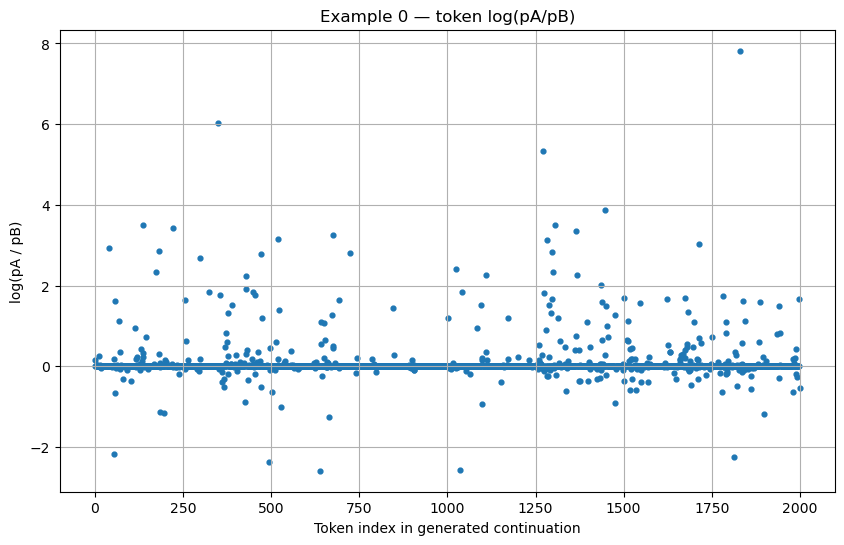

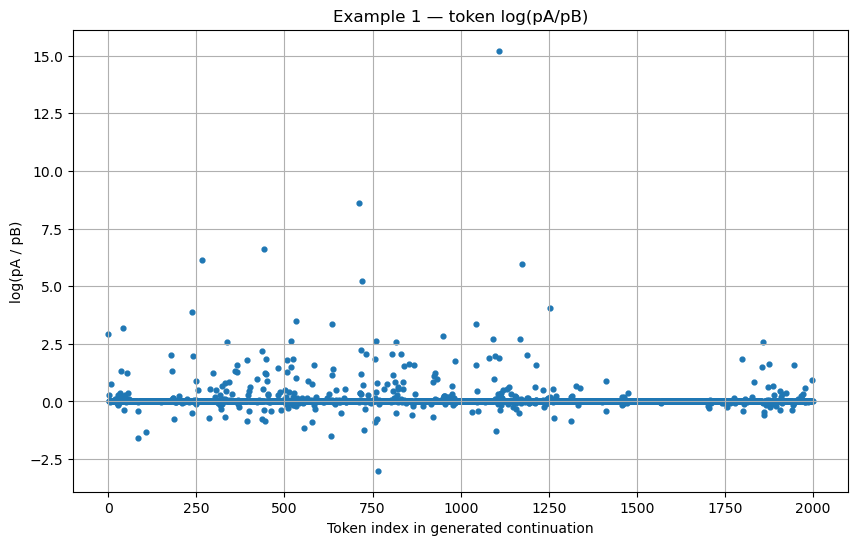

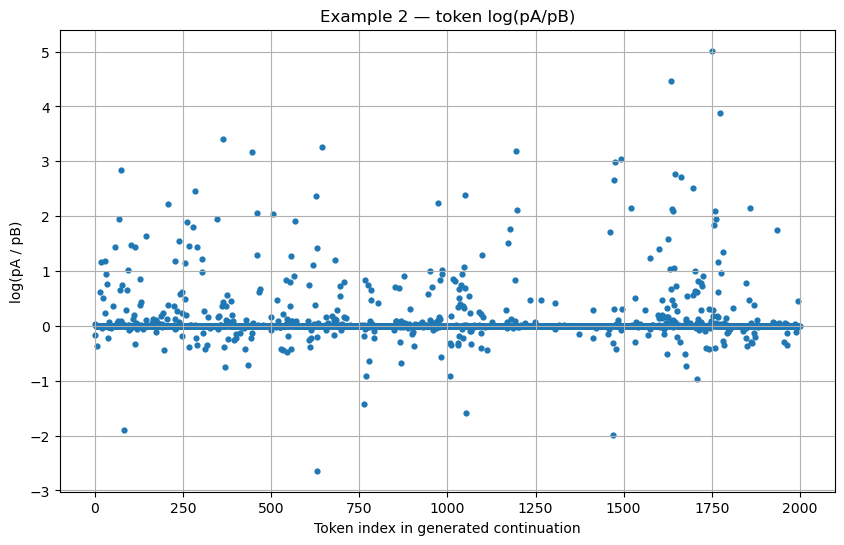

In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

path = "/Data/allegra-maria-pia.boustany/llm_cross_eval/results/exp1_turn1_Qwen3-4B-Thinking-2507_vs_Qwen3-30B-A3B-Thinking-2507_1768215515.csv"
df = pd.read_csv(path)

df["log_ratio"] = np.log(df["ratio_pA_over_pB"].replace([np.inf, -np.inf], np.nan))
df = df.dropna(subset=["log_ratio"])
df[["seed","example_id","token_idx","ratio_pA_over_pB","log_ratio"]].head()

for ex_id, g in df.groupby("example_id"):
    plt.figure(figsize=(10,6))
    plt.title(f"Example {ex_id} — token log(pA/pB)")
    plt.scatter(g["token_idx"], g["log_ratio"], s=12)
    #plt.axhline(g["log_ratio"].mean(), linewidth=1)
    plt.xlabel("Token index in generated continuation")
    plt.ylabel("log(pA / pB)")
    plt.grid(True)
    plt.show()

##### 3000 tokens

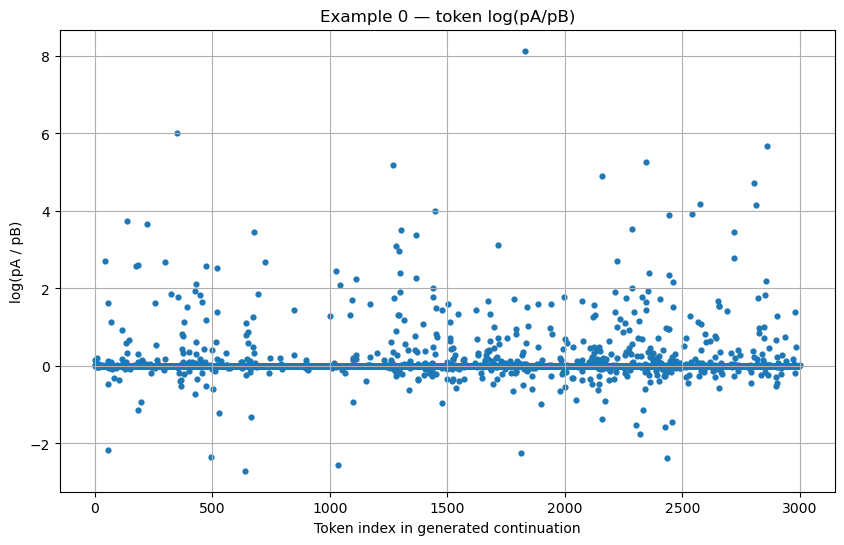

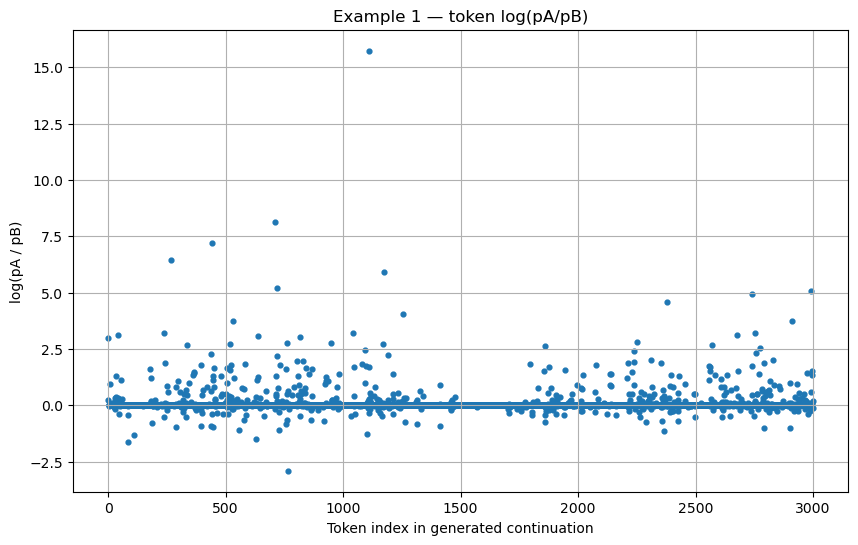

In [5]:
data_2 = "/Data/allegra-maria-pia.boustany/llm_cross_eval/results/exp1_turn1_Qwen3-4B-Thinking-2507_vs_Qwen3-30B-A3B-Thinking-2507_1768221683.csv"

df2 = pd.read_csv(data_2)
df2["log_ratio"] = np.log(df2["ratio_pA_over_pB"].replace([np.inf, -np.inf], np.nan))
df2 = df2.dropna(subset=["log_ratio"])
df2[["seed","example_id","token_idx","ratio_pA_over_pB","log_ratio"]].head()    

for ex_id, g in df2.groupby("example_id"):
    plt.figure(figsize=(10,6))
    plt.title(f"Example {ex_id} — token log(pA/pB)")
    plt.scatter(g["token_idx"], g["log_ratio"], s=12)
    #plt.axhline(g["log_ratio"].mean(), linewidth=1)
    plt.xlabel("Token index in generated continuation")
    plt.ylabel("log(pA / pB)")
    plt.grid(True)
    plt.show()

## Multiple samples

In [13]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

path_3 = "/Data/allegra-maria-pia.boustany/llm_cross_eval/results/exp1_turn1_Qwen3-4B-Thinking-2507_vs_Qwen3-30B-A3B-Thinking-2507_1768225793.csv"

df3 = pd.read_csv(path_3)
df3["log_ratio"] = np.log(df3["ratio_pA_over_pB"].replace([np.inf, -np.inf], np.nan))

df3 = df3.dropna(subset=["log_ratio"])
df3[["seed","example_id","token_idx","ratio_pA_over_pB","log_ratio"]].head()  
df3.groupby(["example_id","seed"])["continuation_text"].first()



example_id  seed
0           1       \n\nOkay, let's try to figure out this problem...
            2       \n\nOkay, let's try to solve this problem step...
            3       \n\nOkay, let's try to solve this problem step...
1           1        \n\nOkay, let's try to tackle this problem st...
            2        \n\nOkay, let's try to tackle this problem st...
            3        \n\nOkay, let's try to tackle this problem st...
Name: continuation_text, dtype: object

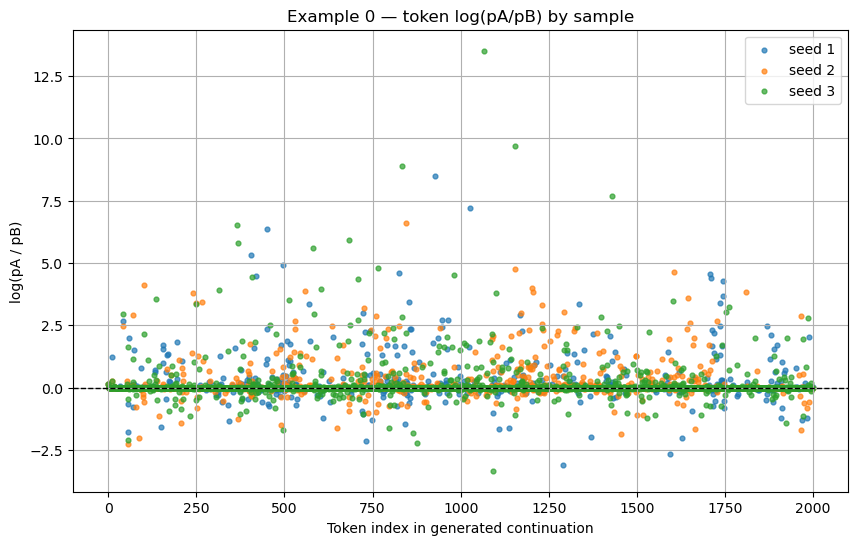

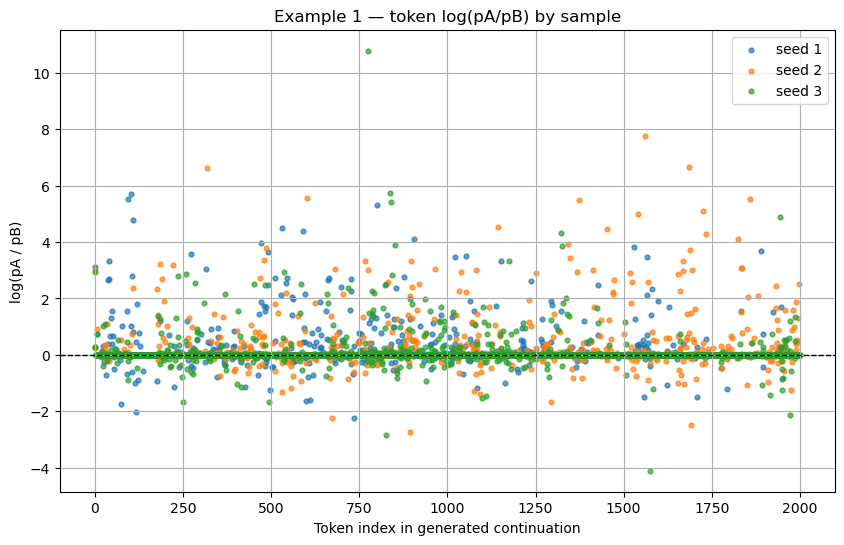

In [9]:
for ex_id, g_ex in df3.groupby("example_id"):
    plt.figure(figsize=(10,6))
    plt.title(f"Example {ex_id} — token log(pA/pB) by sample")

    for seed, g_seed in g_ex.groupby("seed"):
        plt.scatter(
            g_seed["token_idx"],
            g_seed["log_ratio"],
            s=12,
            label=f"seed {seed}",
            alpha=0.7
        )

    plt.xlabel("Token index in generated continuation")
    plt.ylabel("log(pA / pB)")
    plt.axhline(0, linewidth=1, linestyle="--", color="black")
    plt.legend()
    plt.grid(True)
    plt.show()

In [5]:
df3["min_p"] = df3[["p_a","p_b"]].min(axis=1)
df3["max_p"] = df3[["p_a","p_b"]].max(axis=1)

df3["min_p"].describe()


count    1.200000e+04
mean     8.904264e-01
std      2.527558e-01
min      5.043477e-07
25%      9.770735e-01
50%      9.999950e-01
75%      9.999999e-01
max      1.000000e+00
Name: min_p, dtype: float64

In [6]:
spikes = df3.loc[df3["log_ratio"].abs() > 6, ["example_id","seed","token_idx","token_str","p_a","p_b","log_ratio"]]
spikes.head(20)


,example_id,seed,token_idx,token_str,p_a,p_b,log_ratio
449,0,1,449,but,0.399329,6.883246e-04,6.363281
926,0,1,926,d,0.760760,1.584613e-04,8.476562
1026,0,1,1026,substitution,0.293299,2.165910e-04,7.210938
4845,0,2,845,Yes,0.016163,2.144541e-05,6.625000
6317,1,2,317,will,0.006738,8.939776e-06,6.625000
7561,1,2,1561,here,0.088755,3.763786e-05,7.765625
7685,1,2,1685,Let,0.552252,7.101744e-04,6.656250
8366,0,3,366,Hmm,0.597127,8.566338e-04,6.546875
8833,0,3,833,the,0.200013,2.753645e-05,8.890625
9066,0,3,1066,6,0.376603,5.043477e-07,13.523438


#### With Sampling